# Mortality & Lapse Experience Study

**Core question:** is emerging experience consistent with the assumptions used to price the
product?

An experience study is the feedback loop of actuarial pricing. Notebook 03 turned assumptions into
a premium; notebook 05 showed when that premium earns its margin. This notebook asks the question
that closes the loop — *were the assumptions right?* — and, where the evidence is strong enough,
feeds a revised assumption back into the pricing engine.

**Contents**

1. [Defining exposure properly](#Part-1) — exposure, actual, expected, and the denominator fix.
2. [Overall A/E](#Part-2) — the headline ratios and how to read them.
3. [A/E by duration](#Part-3) — with a credibility-aware traffic light.
4. [Segment studies](#Part-4) — is the pricing segmentation adequate?
5. [Credibility](#Part-5) — confidence intervals and partial credibility.
6. [Cumulative actual vs expected](#Part-6) — *when* did experience diverge?
7. [Cohort vs duration effects](#Part-7) — the experience triangle.
8. [Experience-based assumption update](#Part-8) — back to pricing.

> **What is real here and what is simulated.** The *expected* basis is entirely real: the SOA 2015
> VBT tables and the configured lapse curve, exactly as the pricing engine uses them. The *actual*
> experience is simulated, because this project has no real policyholder data — but it is simulated
> against a separately declared "true" basis derived from real SOA studies (ILEC 2012–2019 for
> mortality, the 2009–13 Persistency Update's by-risk-class cut for lapse), which deliberately
> differs from the pricing basis by duration. See `ACTUARIAL_ASSUMPTIONS.md`. So the A/E ratios
> below are not trivially 1.0, and the *methodology* is exactly what an experience-study actuary
> would run — but no conclusion here is a statement about any real insurer's experience.

## Setup

In [1]:
import sys
from pathlib import Path

NOTEBOOK_DIR = Path.cwd()
ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "src").exists() else NOTEBOOK_DIR.parent
if str(ROOT / "src") not in sys.path:
    sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.colors import TwoSlopeNorm
from scipy.stats import chi2

from life_pricing.config import load_assumptions
from life_pricing.mortality import mortality_curve_for_policy, write_processed_tables
from life_pricing.projection import project_policy
from life_pricing.premium import solve_annual_premium
from life_pricing.portfolio import generate_synthetic_portfolio
from life_pricing.experience import (
    simulate_policy_exposures,
    overall_actual_to_expected,
    actual_to_expected_by_segment,
)

BLUE, ORANGE, AQUA, YELLOW, MAGENTA = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4"
INK, SECONDARY_INK, MUTED, GRID, BASELINE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7"
GOOD, WARNING, CRITICAL, NEUTRAL = "#0ca30c", "#fab219", "#d03b3b", "#c3c2b7"

plt.rcParams.update({
    "figure.dpi": 120, "axes.edgecolor": BASELINE, "axes.labelcolor": SECONDARY_INK,
    "axes.titlecolor": INK, "xtick.color": MUTED, "ytick.color": MUTED,
    "text.color": INK, "grid.color": GRID, "font.size": 10,
})


def style(ax, drop_left=False):
    ax.grid(axis="y", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in (["top", "right", "left"] if drop_left else ["top", "right"]):
        ax.spines[spine].set_visible(False)
    return ax


write_processed_tables()
ASSUMPTIONS = load_assumptions(ROOT / "config" / "assumptions.yaml")

portfolio = generate_synthetic_portfolio(ASSUMPTIONS)
exposures = simulate_policy_exposures(ASSUMPTIONS, portfolio)

print(f"Policies:            {len(portfolio):,}")
print(f"Exposure records:    {len(exposures):,} policy-years")
print(f"Study period:        issue years {portfolio['issue_year'].min()}-{portfolio['issue_year'].max()}, "
      f"{ASSUMPTIONS.term_years}-year term")

Policies:            10,000
Exposure records:    126,631 policy-years
Study period:        issue years 2016-2025, 20-year term


<a id="Part-1"></a>
## Part 1 — Define exposure properly

Three concepts do all the work in an experience study, and confusing them is the most common way
to get a wrong answer.

**Exposure** — a policy was *at risk* during a period. Here one exposure record is one
policy-year in which the policy was in force at the start of the year. A policy contributes rows
until (and including) the year it dies, lapses, or completes the term. A policy that lapses in
year 4 contributes exactly 4 exposure records, not 20 — it was never at risk in years 5–20.

**Actual** — the events actually observed: `actual_death`, `actual_lapse` (0/1 per exposure).

**Expected** — what the pricing model predicted for that same exposure. This is where care is
needed, because *expected* must be defined on the same basis as *actual*.

$$ E[D_t] = Exposure_t \times q_t $$

$$ E[L_t] = Exposure_t \,(1 - q_t)\, l_t $$

### The denominator fix

The lapse formula is the subtle one, and this project got it wrong before V1.1. Under the
competing-decrement convention used throughout (`PROJECT_SPEC.md` section 7), mortality is applied
*before* lapse within a policy year:

$$ D_t = I_t q_t, \qquad L_t = I_t (1-q_t) l_t $$

The simulation already respected this — a policy can only be sampled to lapse in a year it did not
die. But the A/E aggregation summed the raw table rate $l_t$ as the expected-lapse denominator,
which is the probability of lapsing *given the policy is known to be in force at the start of the
year*, not the probability of lapsing within the year once mortality is also in play. Comparing an
actual that is conditional on surviving mortality against an expected that is not is an
apples-to-oranges ratio.

The exposure table now carries both explicitly. Let us verify the identity and measure the size of
the error.

In [2]:
print("Exposure table columns:", list(exposures.columns))
exposures.head(8)

Exposure table columns: ['policy_id', 'policy_year', 'expected_qx', 'expected_lapse_rate', 'expected_death_probability', 'expected_lapse_probability', 'actual_death', 'actual_lapse']


,policy_id,policy_year,expected_qx,expected_lapse_rate,expected_death_probability,expected_lapse_probability,actual_death,actual_lapse
0,POL-000001,1,0.000160,0.060,0.000160,0.059990,0,0
1,POL-000001,2,0.000205,0.055,0.000205,0.054989,0,0
2,POL-000001,3,0.000319,0.047,0.000319,0.046985,0,0
3,POL-000001,4,0.000494,0.043,0.000494,0.042979,0,0
4,POL-000001,5,0.000563,0.040,0.000563,0.039977,0,0
5,POL-000001,6,0.000616,0.037,0.000616,0.036977,0,0
6,POL-000001,7,0.000669,0.034,0.000669,0.033977,0,0
7,POL-000001,8,0.000775,0.032,0.000775,0.031975,0,0


In [3]:
identity_error = (
    exposures["expected_lapse_probability"]
    - (1 - exposures["expected_qx"]) * exposures["expected_lapse_rate"]
).abs().max()
print(f"Max |expected_lapse_probability - (1-q)*l| = {identity_error:.2e}   "
      f"{'PASS' if identity_error < 1e-12 else 'FAIL'}")
print()

actual_lapses = exposures["actual_lapse"].sum()
correct_denominator = exposures["expected_lapse_probability"].sum()
buggy_denominator = exposures["expected_lapse_rate"].sum()

print(f"Actual lapses observed                       {actual_lapses:>12,}")
print(f"Expected lapses, CORRECT  sum (1-q)*l        {correct_denominator:>12,.2f}")
print(f"Expected lapses, pre-V1.1 sum l              {buggy_denominator:>12,.2f}")
print()
print(f"A/E lapse, correct   = {actual_lapses / correct_denominator:.4f}")
print(f"A/E lapse, pre-V1.1  = {actual_lapses / buggy_denominator:.4f}")
print(f"Understatement       = {actual_lapses / buggy_denominator - actual_lapses / correct_denominator:+.4f}")

Max |expected_lapse_probability - (1-q)*l| = 0.00e+00   PASS

Actual lapses observed                              6,326
Expected lapses, CORRECT  sum (1-q)*l            5,894.94
Expected lapses, pre-V1.1 sum l                  5,911.42

A/E lapse, correct   = 1.0731
A/E lapse, pre-V1.1  = 1.0701
Understatement       = -0.0030


The bias is small here — because $q_t$ is tiny at these ages, $(1-q_t) \approx 1$ — but it is
*systematically* in one direction, and it would grow with age or on a product sold to impaired
lives. The reason to fix it is not the magnitude: it is that an A/E ratio whose numerator and
denominator are defined on different conditioning sets does not measure anything well-defined.

<a id="Part-2"></a>
## Part 2 — Overall A/E

$$ A/E_{mort} = \frac{\sum D^{Actual}}{\sum D^{Expected}}, \qquad
   A/E_{lapse} = \frac{\sum L^{Actual}}{\sum L^{Expected}} $$

| Result | Meaning |
|---|---|
| $A/E = 1.00$ | experience exactly as assumed |
| $A/E > 1$ | *more* events than expected — worse mortality, or heavier lapsation |
| $A/E < 1$ | *fewer* events than expected — better mortality, or stickier business |

Note the asymmetry in what "good" means: $A/E_{mort} < 1$ is favourable to the insurer (fewer
claims), whereas $A/E_{lapse} \ne 1$ is not automatically good or bad — notebook 05 showed that for
this lapse-supported product, *more* lapses after duration 3 actually increase profit.

In [4]:
overall = overall_actual_to_expected(exposures)

summary = pd.DataFrame({
    "Metric": ["Exposure (policy-years)", "Actual events", "Expected events", "A/E ratio"],
    "Mortality": [
        f"{len(exposures):,}",
        f"{overall['actual_deaths']:,.0f}",
        f"{overall['expected_deaths']:,.1f}",
        f"{overall['ae_mortality']:.4f}",
    ],
    "Lapse": [
        f"{len(exposures):,}",
        f"{overall['actual_lapses']:,.0f}",
        f"{overall['expected_lapses']:,.1f}",
        f"{overall['ae_lapse']:.4f}",
    ],
})
summary.set_index("Metric")

,Mortality,Lapse
Metric,,
Exposure (policy-years),"126,631","126,631"
Actual events,204,"6,326"
Expected events,275.9,"5,894.9"
A/E ratio,0.7394,1.0731


In [5]:
event_rate = overall["actual_deaths"] / len(exposures)
print(f"Crude mortality rate = {overall['actual_deaths']:,.0f} deaths / {len(exposures):,} policy-years "
      f"= {event_rate:.4%}")
print()
print(f"A/E mortality = {overall['ae_mortality']:.3f}  ->  actual mortality is running "
      f"{1 - overall['ae_mortality']:.1%} BELOW the pricing basis.")
print(f"A/E lapse     = {overall['ae_lapse']:.3f}  ->  actual lapsation is running "
      f"{overall['ae_lapse'] - 1:.1%} ABOVE the pricing basis.")

Crude mortality rate = 204 deaths / 126,631 policy-years = 0.1611%

A/E mortality = 0.739  ->  actual mortality is running 26.1% BELOW the pricing basis.
A/E lapse     = 1.073  ->  actual lapsation is running 7.3% ABOVE the pricing basis.


Mortality is running well below the 2015 VBT pricing basis. That direction is expected and
realistic — VBT is a broad industry table, while these are recently underwritten lives who passed
selection, and the real ILEC study the "true" basis is drawn from shows exactly this pattern. It
is favourable news for the insurer, but as Part 5 will show, "favourable" and "credible enough to
act on" are different questions.

<a id="Part-3"></a>
## Part 3 — A/E by duration

In [6]:
def ae_table(frame, group_columns, kind="mortality"):
    """A/E table with Poisson confidence bounds and limited-fluctuation credibility.

    `kind` selects mortality or lapse columns; both use the correct
    competing-decrement denominators from life_pricing.experience.
    """

    actual_col = "actual_death" if kind == "mortality" else "actual_lapse"
    expected_col = "expected_death_probability" if kind == "mortality" else "expected_lapse_probability"

    table = (
        frame.groupby(group_columns, observed=True)
        .agg(exposure=("policy_id", "count"), actual=(actual_col, "sum"), expected=(expected_col, "sum"))
        .reset_index()
    )
    table["ae"] = table["actual"] / table["expected"]
    lower, upper = poisson_ae_interval(table["actual"], table["expected"])
    table["ae_lower"], table["ae_upper"] = lower, upper
    table["credibility_Z"] = np.minimum(1.0, np.sqrt(table["expected"] / FULL_CREDIBILITY_CLAIMS))
    table["significant"] = (table["ae_lower"] > 1.0) | (table["ae_upper"] < 1.0)
    return table


def poisson_ae_interval(actual, expected, confidence=0.95):
    """Exact (Garwood) Poisson confidence interval for A/E.

    Treating Actual ~ Poisson(Expected * theta), an exact interval for the
    event count divided by Expected gives an interval for theta = A/E.
    """

    alpha = 1 - confidence
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)
    lower = np.where(actual > 0, chi2.ppf(alpha / 2, 2 * actual) / 2, 0.0)
    upper = chi2.ppf(1 - alpha / 2, 2 * (actual + 1)) / 2
    return lower / expected, upper / expected


# Limited-fluctuation ("classical") full-credibility standard for Poisson counts:
# n_full = (z / k)^2 with z = 1.645 (90% confidence) and k = 0.05 (within +/-5%).
FULL_CREDIBILITY_CLAIMS = (1.645 / 0.05) ** 2
print(f"Full-credibility standard: {FULL_CREDIBILITY_CLAIMS:,.0f} expected claims "
      f"(90% confidence of being within +/-5%)")

Full-credibility standard: 1,082 expected claims (90% confidence of being within +/-5%)


In [7]:
duration_mortality = ae_table(exposures, ["policy_year"], kind="mortality")
duration_lapse = ae_table(exposures, ["policy_year"], kind="lapse")

display_table = duration_mortality[["policy_year", "exposure", "actual", "expected", "ae", "ae_lower", "ae_upper", "credibility_Z"]].copy()
display_table.columns = ["Duration", "Exposure", "Actual Deaths", "Expected Deaths", "A/E", "95% Lower", "95% Upper", "Z"]
display_table = display_table.set_index("Duration")
for col in ["Expected Deaths", "A/E", "95% Lower", "95% Upper", "Z"]:
    display_table[col] = display_table[col].map(lambda x: f"{x:,.3f}")
display_table["Exposure"] = display_table["Exposure"].map(lambda x: f"{x:,}")
display_table

,Exposure,Actual Deaths,Expected Deaths,A/E,95% Lower,95% Upper,Z
Duration,,,,,,,
1,"10,000",2,2.914,0.686,0.083,2.479,0.052
2,"9,102",6,4.331,1.385,0.508,3.016,0.063
3,"8,441",4,5.850,0.684,0.186,1.751,0.074
4,"7,920",4,6.896,0.580,0.158,1.485,0.080
5,"7,493",6,7.712,0.778,0.286,1.693,0.084
6,"7,102",5,8.412,0.594,0.193,1.387,0.088
7,"6,779",6,9.187,0.653,0.240,1.422,0.092
8,"6,527",13,10.084,1.289,0.686,2.205,0.097
9,"6,293",10,11.045,0.905,0.434,1.665,0.101


### A credibility-aware traffic light

The classic traffic light colours an A/E ratio by how far it sits from 1.00:

| Band | A/E |
|---|---|
| Green | 0.90 – 1.10 |
| Yellow | 0.80 – 0.90 or 1.10 – 1.20 |
| Red | < 0.80 or > 1.20 |

Applied naively this is actively misleading, because it treats a ratio built on 2 expected deaths
identically to one built on 500. So the version below adds a gate: **a cell is only coloured if its
95% confidence interval excludes 1.00.** If the interval contains 1.00, the segment is grey — "not
distinguishable from the assumption", regardless of how dramatic the point estimate looks.

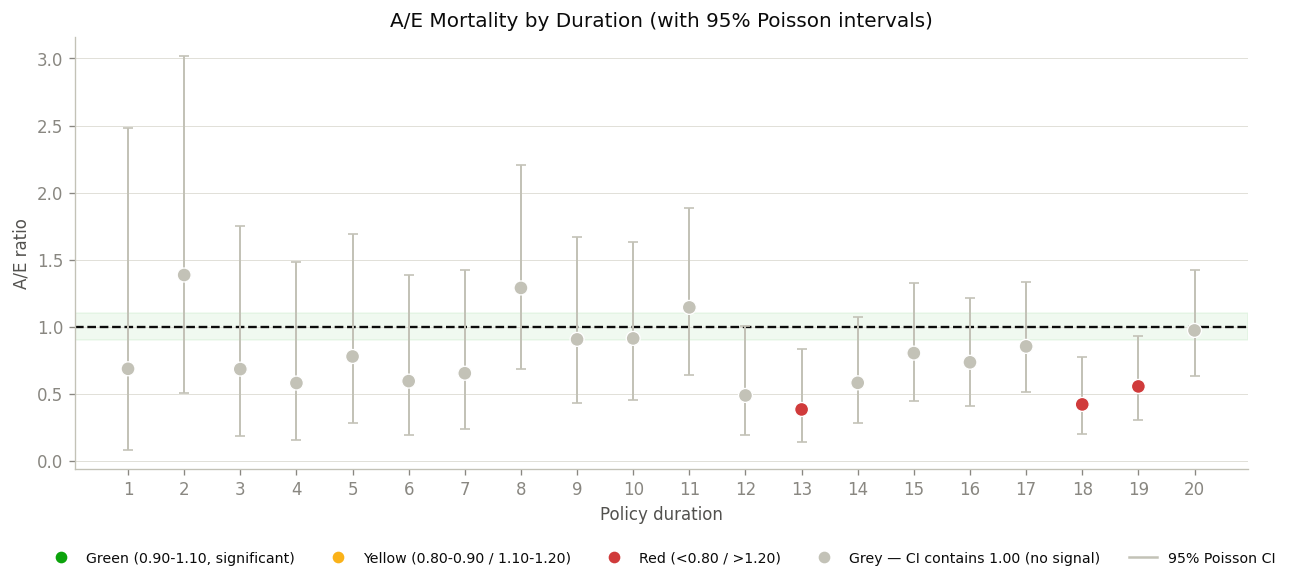

In [8]:
def traffic_light(row):
    """Colour only if the interval excludes 1.0; otherwise the result is noise."""

    if not row["significant"]:
        return NEUTRAL
    ae = row["ae"]
    if 0.90 <= ae <= 1.10:
        return GOOD
    if 0.80 <= ae < 0.90 or 1.10 < ae <= 1.20:
        return WARNING
    return CRITICAL


def plot_ae_by_duration(table, title, ylabel="A/E ratio"):
    fig, ax = plt.subplots(figsize=(11.5, 5))
    colors = [traffic_light(row) for _, row in table.iterrows()]
    x = table["policy_year"]

    ax.errorbar(
        x, table["ae"],
        yerr=[table["ae"] - table["ae_lower"], table["ae_upper"] - table["ae"]],
        fmt="none", ecolor=BASELINE, elinewidth=1.2, capsize=3, zorder=2,
    )
    ax.scatter(x, table["ae"], c=colors, s=70, zorder=3, edgecolors="white", linewidths=0.8)
    ax.axhline(1.0, color=INK, linewidth=1.4, linestyle="--", zorder=1)
    ax.axhspan(0.90, 1.10, color=GOOD, alpha=0.06, zorder=0)

    ax.set_xlabel("Policy duration")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.set_xticks(list(x))
    style(ax)

    handles = [
        plt.Line2D([], [], marker="o", linestyle="", color=GOOD, label="Green (0.90-1.10, significant)"),
        plt.Line2D([], [], marker="o", linestyle="", color=WARNING, label="Yellow (0.80-0.90 / 1.10-1.20)"),
        plt.Line2D([], [], marker="o", linestyle="", color=CRITICAL, label="Red (<0.80 / >1.20)"),
        plt.Line2D([], [], marker="o", linestyle="", color=NEUTRAL, label="Grey — CI contains 1.00 (no signal)"),
        plt.Line2D([], [], color=BASELINE, label="95% Poisson CI"),
    ]
    ax.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, -0.16),
              ncol=5, frameon=False, fontsize=8.5)
    plt.tight_layout()
    plt.show()


plot_ae_by_duration(duration_mortality, "A/E Mortality by Duration (with 95% Poisson intervals)")

In [9]:
significant_count = duration_mortality["significant"].sum()
print(f"Durations where the 95% CI excludes 1.00: {significant_count} of {len(duration_mortality)}")
print(f"Largest expected-death count in any single duration: {duration_mortality['expected'].max():.1f}")
print(f"Maximum credibility Z at duration level: {duration_mortality['credibility_Z'].max():.3f}")

Durations where the 95% CI excludes 1.00: 3 of 20
Largest expected-death count in any single duration: 26.7
Maximum credibility Z at duration level: 0.157


This is the single most important result in the notebook, and it is a negative one: **at
duration level, this study cannot detect anything about mortality.** The largest duration has
fewer than 27 expected deaths against a full-credibility standard of 1,082, giving a maximum
credibility factor around 0.16. The point estimates swing between roughly 0.38 and 1.39, and a
naive traffic light would paint that chart red and amber and invite a story about "deterioration at
duration 12." The confidence intervals say the honest thing: almost none of that variation is
distinguishable from noise.

Lapse is a completely different matter, because lapses are roughly 30 times more common than
deaths.

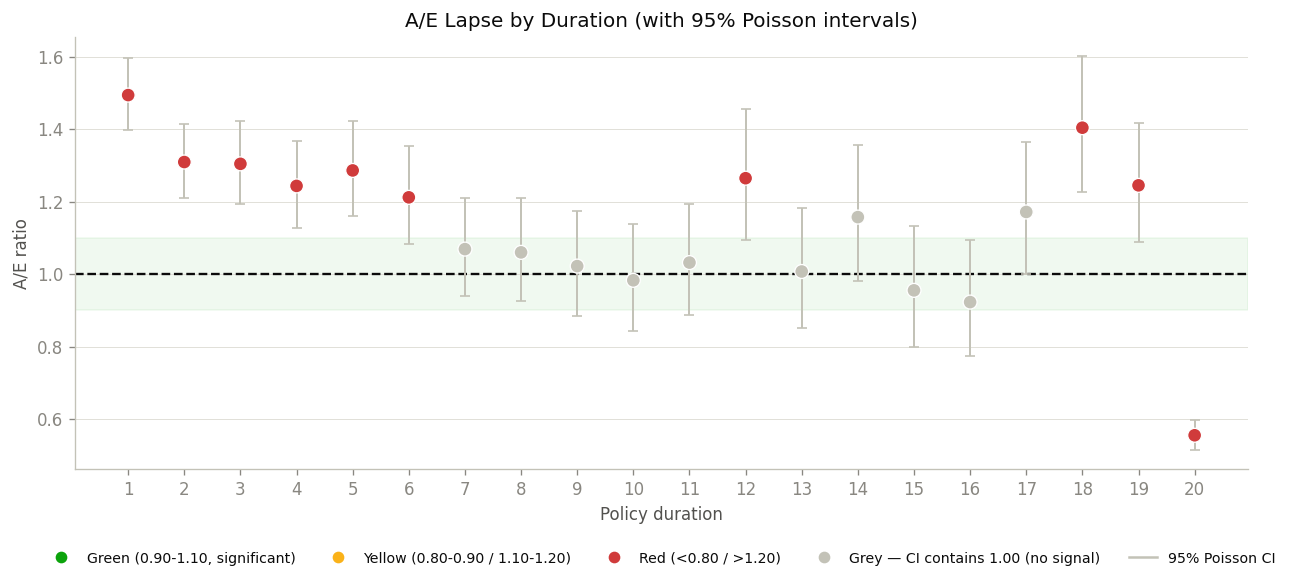

Durations where the 95% CI excludes 1.00: 10 of 20
Total expected lapses: 5,895  (vs 276 expected deaths)


In [10]:
plot_ae_by_duration(duration_lapse, "A/E Lapse by Duration (with 95% Poisson intervals)")

print(f"Durations where the 95% CI excludes 1.00: {duration_lapse['significant'].sum()} of {len(duration_lapse)}")
print(f"Total expected lapses: {duration_lapse['expected'].sum():,.0f}  "
      f"(vs {duration_mortality['expected'].sum():,.0f} expected deaths)")

Here there is real, statistically significant structure: lapses run materially **above** assumption
in the early durations, drift back toward the assumption in the middle of the term, and fall well
**below** assumption at duration 20. That last point is not a data problem — duration 20 is the
end-of-level-period shock lapse (31% assumed), and the study says the assumed spike is too large.

Note also the confidence intervals are visibly tighter here than in the mortality chart: same
study, same policies, but ~5,900 expected events instead of ~276. Credibility is about event
counts, not policy counts.

<a id="Part-4"></a>
## Part 4 — Segment studies

Is the pricing segmentation adequate? If the pricing basis already captures a risk dimension
correctly, A/E should be roughly *flat* across that dimension. A systematic gradient means the
assumption's relativities are off.

In [11]:
SEGMENTS = ["issue_age_band", "sex", "smoker_status", "underwriting_class",
            "face_amount_band", "issue_cohort", "distribution_channel"]

portfolio_bands = portfolio.copy()
from life_pricing.experience import issue_age_band, face_amount_band
portfolio_bands["issue_age_band"] = portfolio_bands["issue_age"].apply(issue_age_band)
portfolio_bands["face_amount_band"] = portfolio_bands["face_amount"].apply(face_amount_band)
portfolio_bands["issue_cohort"] = portfolio_bands["issue_year"]

enriched = exposures.merge(portfolio_bands[["policy_id"] + SEGMENTS], on="policy_id", how="left")

segment_results = {}
for segment in SEGMENTS:
    segment_results[segment] = ae_table(enriched, [segment], kind="mortality")

for segment in SEGMENTS:
    table = segment_results[segment]
    formatted = table[[segment, "exposure", "actual", "expected", "ae", "ae_lower", "ae_upper", "credibility_Z", "significant"]].copy()
    formatted.columns = [segment, "Exposure", "Actual", "Expected", "A/E", "Lower", "Upper", "Z", "Signif."]
    for col in ["Expected", "A/E", "Lower", "Upper", "Z"]:
        formatted[col] = formatted[col].map(lambda x: f"{x:,.3f}")
    formatted["Exposure"] = formatted["Exposure"].map(lambda x: f"{x:,}")
    print(f"\n=== A/E mortality by {segment} ===")
    print(formatted.to_string(index=False))


=== A/E mortality by issue_age_band ===
issue_age_band Exposure  Actual Expected   A/E Lower Upper     Z  Signif.
         25-34   36,351      14   18.476 0.758 0.414 1.271 0.131    False
         35-44   35,855      36   39.031 0.922 0.646 1.277 0.190    False
         45-54   34,612      82   98.193 0.835 0.664 1.037 0.301    False
         55-60   19,813      72  120.209 0.599 0.469 0.754 0.333     True

=== A/E mortality by sex ===
   sex Exposure  Actual Expected   A/E Lower Upper     Z  Signif.
female   63,657      91  117.044 0.777 0.626 0.955 0.329     True
  male   62,974     113  158.865 0.711 0.586 0.855 0.383     True

=== A/E mortality by smoker_status ===
smoker_status Exposure  Actual Expected   A/E Lower Upper     Z  Signif.
    nonsmoker  108,319     147  189.135 0.777 0.657 0.914 0.418     True
       smoker   18,312      57   86.774 0.657 0.498 0.851 0.283     True

=== A/E mortality by underwriting_class ===
underwriting_class Exposure  Actual Expected   A/E Lower 

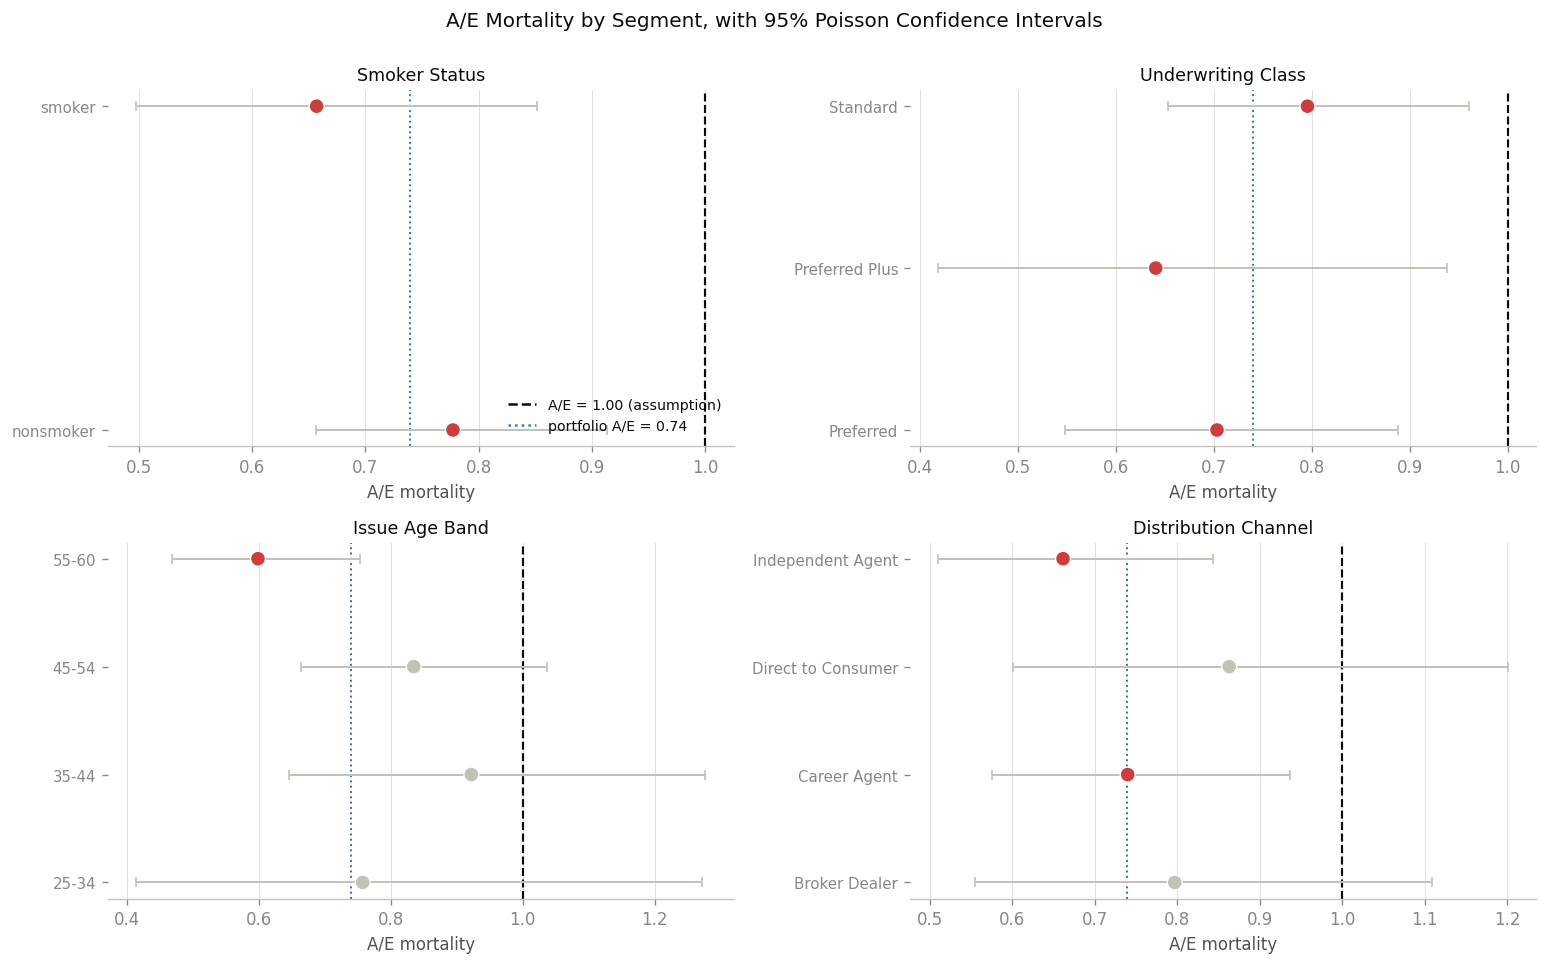

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
panels = ["smoker_status", "underwriting_class", "issue_age_band", "distribution_channel"]

for ax, segment in zip(axes.flat, panels):
    table = segment_results[segment].copy()
    labels = table[segment].astype(str)
    positions = np.arange(len(table))
    colors = [traffic_light(row) for _, row in table.iterrows()]

    ax.errorbar(table["ae"], positions,
                xerr=[table["ae"] - table["ae_lower"], table["ae_upper"] - table["ae"]],
                fmt="none", ecolor=BASELINE, elinewidth=1.2, capsize=3, zorder=2)
    ax.scatter(table["ae"], positions, c=colors, s=80, zorder=3, edgecolors="white", linewidths=0.8)
    ax.axvline(1.0, color=INK, linewidth=1.3, linestyle="--", zorder=1)
    ax.axvline(overall["ae_mortality"], color=BLUE, linewidth=1.2, linestyle=":", zorder=1)

    ax.set_yticks(positions)
    ax.set_yticklabels(labels, fontsize=9)
    ax.set_xlabel("A/E mortality")
    ax.set_title(segment.replace("_", " ").title(), fontsize=10.5)
    ax.grid(axis="x", linewidth=0.6, zorder=0)
    ax.set_axisbelow(True)
    for spine in ["top", "right", "left"]:
        ax.spines[spine].set_visible(False)

handles = [
    plt.Line2D([], [], color=INK, linestyle="--", label="A/E = 1.00 (assumption)"),
    plt.Line2D([], [], color=BLUE, linestyle=":", label=f"portfolio A/E = {overall['ae_mortality']:.2f}"),
]
axes.flat[0].legend(handles=handles, loc="lower right", frameon=False, fontsize=8.5)
fig.suptitle("A/E Mortality by Segment, with 95% Poisson Confidence Intervals", fontsize=12, y=1.00)
plt.tight_layout()
plt.show()

### Reading the segment results

Every segment sits below 1.00, which simply restates the portfolio-level finding: the VBT basis is
conservative for this book. The question that matters for *segmentation* is not the level but
whether segments differ **from each other** in a way the pricing relativities do not already
capture.

Two things are worth flagging. First, essentially every confidence interval overlaps the
portfolio-wide A/E (the dotted line), so on this evidence there is no defensible case that any
particular segment's relativity is wrong — the differences between segments are within noise, even
where the point estimates look suggestive. Second, the *issue cohort* dimension in the table above
is the useful control: the simulation contains no cohort effect by construction, so the scatter
across issue years (charted in Part 7) is a direct read on how much apparent signal pure noise
produces at this sample size. Any real segment
finding has to be more convincing than that.

The worked example in the brief — $A/E_{\text{Preferred Plus}} = 1.18$ suggesting preferred
assumptions are too aggressive, against $A/E_{\text{Standard}} = 0.91$ suggesting Standard is
conservative — is exactly the right *interpretation* if those numbers were credible. What this
study shows is that at 10,000 policies and ~276 expected deaths, they would not be.

<a id="Part-5"></a>
## Part 5 — Credibility

The motivating comparison from the brief:

| | Expected deaths | Actual deaths | A/E |
|---|---:|---:|---:|
| Segment A | 2 | 4 | 200% |
| Segment B | 500 | 600 | 120% |

Segment A's 200% is far more dramatic and far less believable. Modelling
$Actual \sim Poisson(Expected \times \theta)$ makes the difference precise.

In [13]:
demo = pd.DataFrame({"Segment": ["A", "B"], "Expected": [2.0, 500.0], "Actual": [4, 600]})
demo["A/E"] = demo["Actual"] / demo["Expected"]
lower, upper = poisson_ae_interval(demo["Actual"], demo["Expected"])
demo["95% Lower"], demo["95% Upper"] = lower, upper
demo["CI width"] = demo["95% Upper"] - demo["95% Lower"]
demo["Credibility Z"] = np.minimum(1.0, np.sqrt(demo["Expected"] / FULL_CREDIBILITY_CLAIMS))
demo["Excludes 1.0?"] = (demo["95% Lower"] > 1.0) | (demo["95% Upper"] < 1.0)

demo_display = demo.copy()
for col in ["A/E", "95% Lower", "95% Upper", "CI width", "Credibility Z"]:
    demo_display[col] = demo_display[col].map(lambda x: f"{x:.3f}")
demo_display.set_index("Segment")

,Expected,Actual,A/E,95% Lower,95% Upper,CI width,Credibility Z,Excludes 1.0?
Segment,,,,,,,,
A,2.0,4,2.000,0.545,5.121,4.576,0.043,False
B,500.0,600,1.200,1.106,1.300,0.194,0.680,True


Segment A's interval spans an enormous range and comfortably contains 1.00 — four deaths against
two expected is entirely ordinary Poisson variation. Segment B's much *smaller* A/E of 1.20 is
supported by an interval that excludes 1.00, so it is real. **The larger ratio is the weaker
finding.** This is why A/E must never be reported without an exposure measure beside it.

### Partial credibility

Limited-fluctuation ("classical") credibility assigns a weight

$$ Z = \min\left(1, \sqrt{\frac{\text{expected claims}}{n_{full}}}\right),
   \qquad n_{full} = \left(\frac{z}{k}\right)^2 = \left(\frac{1.645}{0.05}\right)^2 \approx 1{,}082 $$

so that a segment with a quarter of the required claims gets half the weight. Part 8 uses this to
blend observed experience with the existing assumption rather than over-reacting to it.

In [14]:
credibility_rows = []
for segment in SEGMENTS:
    table = segment_results[segment]
    credibility_rows.append({
        "Segment dimension": segment,
        "Cells": len(table),
        "Min expected deaths": table["expected"].min(),
        "Max expected deaths": table["expected"].max(),
        "Max Z": table["credibility_Z"].max(),
        "Cells with CI excluding 1.0": int(table["significant"].sum()),
    })

credibility_summary = pd.DataFrame(credibility_rows).set_index("Segment dimension")
credibility_summary_display = credibility_summary.copy()
for col in ["Min expected deaths", "Max expected deaths", "Max Z"]:
    credibility_summary_display[col] = credibility_summary_display[col].map(lambda x: f"{x:,.2f}")
credibility_summary_display

,Cells,Min expected deaths,Max expected deaths,Max Z,Cells with CI excluding 1.0
Segment dimension,,,,,
issue_age_band,4,18.48,120.21,0.33,1
sex,2,117.04,158.87,0.38,2
smoker_status,2,86.77,189.14,0.42,2
underwriting_class,3,40.60,135.75,0.35,3
face_amount_band,4,50.08,77.77,0.27,2
issue_cohort,10,25.20,30.53,0.17,2
distribution_channel,4,40.55,98.22,0.30,2


In [15]:
total_expected_deaths = overall["expected_deaths"]
total_expected_lapses = overall["expected_lapses"]
Z_mortality = min(1.0, np.sqrt(total_expected_deaths / FULL_CREDIBILITY_CLAIMS))
Z_lapse = min(1.0, np.sqrt(total_expected_lapses / FULL_CREDIBILITY_CLAIMS))

print(f"Full-credibility standard:        {FULL_CREDIBILITY_CLAIMS:,.0f} expected events")
print()
print(f"MORTALITY: {total_expected_deaths:,.0f} expected deaths  ->  Z = {Z_mortality:.4f}  (partially credible)")
print(f"LAPSE:     {total_expected_lapses:,.0f} expected lapses  ->  Z = {Z_lapse:.4f}  (fully credible)")
print()
policies_needed = len(portfolio) * FULL_CREDIBILITY_CLAIMS / total_expected_deaths
print(f"To reach full mortality credibility at this book's mix would take roughly "
      f"{policies_needed:,.0f} policies")
print(f"-- about {policies_needed / len(portfolio):.0f}x the current book.")

Full-credibility standard:        1,082 expected events

MORTALITY: 276 expected deaths  ->  Z = 0.5049  (partially credible)
LAPSE:     5,895 expected lapses  ->  Z = 1.0000  (fully credible)

To reach full mortality credibility at this book's mix would take roughly 39,231 policies
-- about 4x the current book.


This is the practical reality of mortality experience studies and the reason they are pooled across
years, companies, and industry bodies like the SOA. A single insurer with 10,000 term policies
simply cannot self-certify a mortality assumption; it *can* credibly study its own lapse
experience, which is why lapse assumptions are far more often company-specific while mortality
leans on industry tables.

<a id="Part-6"></a>
## Part 6 — Actual vs expected cumulative curves

$$ CumE_t = \sum_{j \le t} E_j, \qquad CumA_t = \sum_{j \le t} A_j $$

A single lifetime A/E ratio hides *when* divergence happened. Cumulative curves answer that
directly: parallel lines mean experience tracks assumption; a widening gap means a persistent
bias; a kink means something changed at a specific duration.

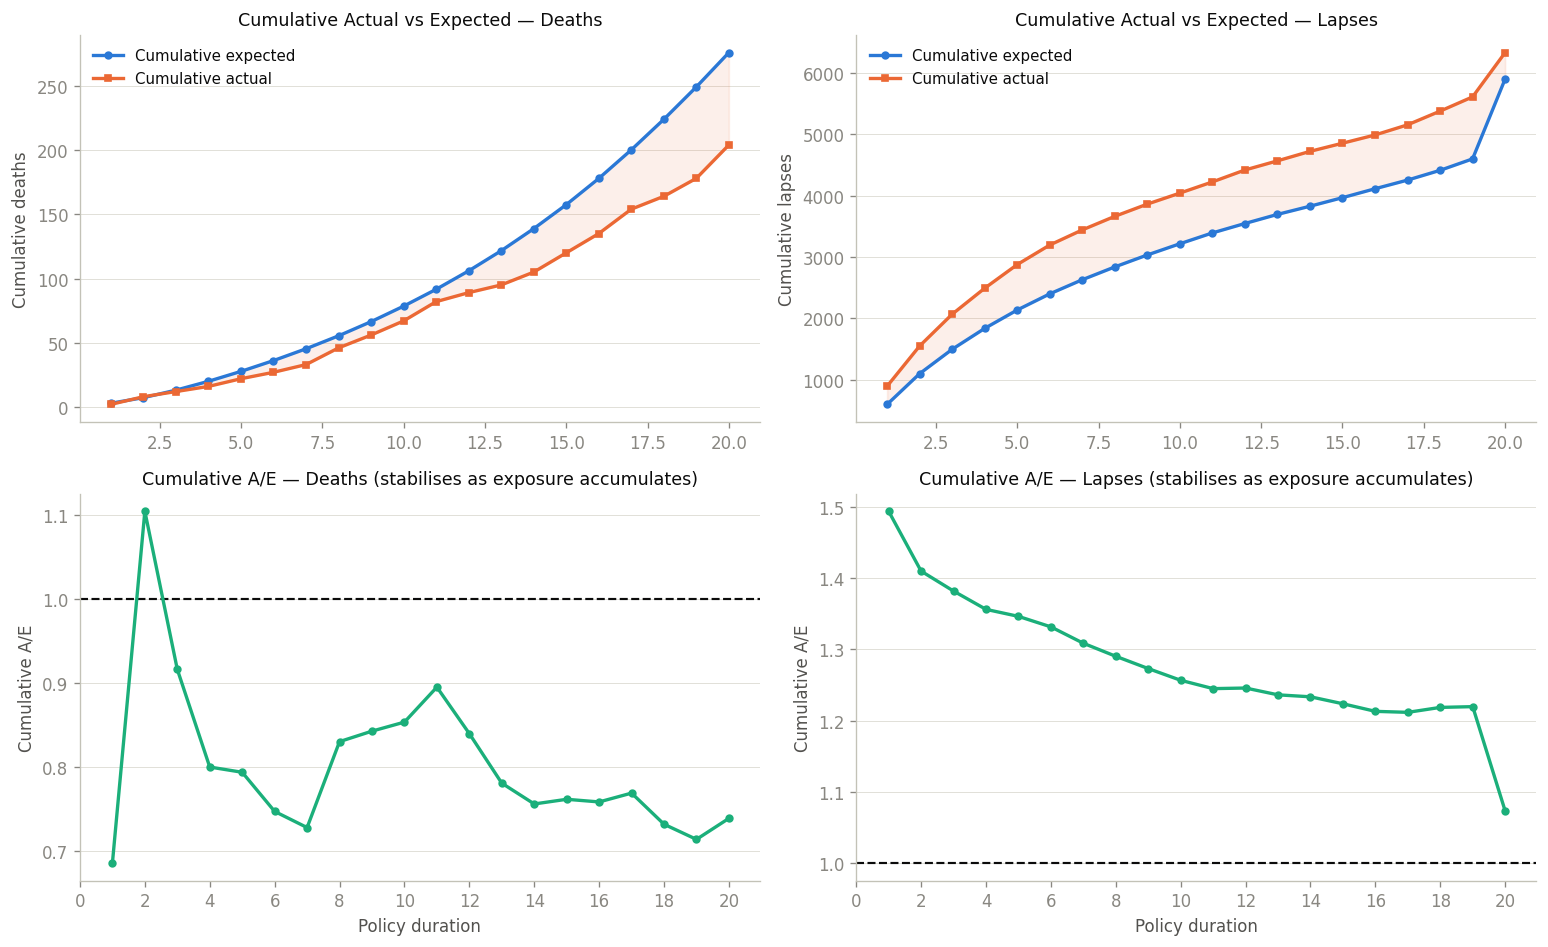

In [16]:
def cumulative_frame(table):
    frame = table.sort_values("policy_year").copy()
    frame["cum_actual"] = frame["actual"].cumsum()
    frame["cum_expected"] = frame["expected"].cumsum()
    frame["cum_ae"] = frame["cum_actual"] / frame["cum_expected"]
    return frame


cumulative_mortality = cumulative_frame(duration_mortality)
cumulative_lapse = cumulative_frame(duration_lapse)

fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for column, (frame, label) in enumerate([(cumulative_mortality, "Deaths"), (cumulative_lapse, "Lapses")]):
    top, bottom = axes[0, column], axes[1, column]

    top.plot(frame["policy_year"], frame["cum_expected"], color=BLUE, marker="o", markersize=4,
             linewidth=2, label="Cumulative expected", zorder=3)
    top.plot(frame["policy_year"], frame["cum_actual"], color=ORANGE, marker="s", markersize=4,
             linewidth=2, label="Cumulative actual", zorder=3)
    top.fill_between(frame["policy_year"], frame["cum_expected"], frame["cum_actual"],
                     color=ORANGE, alpha=0.10, zorder=2)
    top.set_ylabel(f"Cumulative {label.lower()}")
    top.set_title(f"Cumulative Actual vs Expected — {label}", fontsize=10.5)
    top.legend(loc="upper left", frameon=False, fontsize=9)
    style(top)

    bottom.plot(frame["policy_year"], frame["cum_ae"], color=AQUA, marker="o", markersize=4, linewidth=2, zorder=3)
    bottom.axhline(1.0, color=INK, linewidth=1.3, linestyle="--", zorder=1)
    bottom.set_xlabel("Policy duration")
    bottom.set_ylabel("Cumulative A/E")
    bottom.set_title(f"Cumulative A/E — {label} (stabilises as exposure accumulates)", fontsize=10.5)
    bottom.set_xticks(range(0, ASSUMPTIONS.term_years + 1, 2))
    style(bottom)

plt.tight_layout()
plt.show()

In [17]:
print("Cumulative A/E mortality as the study accumulates exposure:")
for duration in [1, 2, 3, 5, 10, 15, 20]:
    row = cumulative_mortality[cumulative_mortality["policy_year"] == duration].iloc[0]
    print(f"  through duration {duration:2d}: A/E = {row['cum_ae']:.3f}   "
          f"({row['cum_actual']:>3.0f} actual vs {row['cum_expected']:>6.1f} expected)")

Cumulative A/E mortality as the study accumulates exposure:
  through duration  1: A/E = 0.686   (  2 actual vs    2.9 expected)
  through duration  2: A/E = 1.104   (  8 actual vs    7.2 expected)
  through duration  3: A/E = 0.916   ( 12 actual vs   13.1 expected)
  through duration  5: A/E = 0.794   ( 22 actual vs   27.7 expected)
  through duration 10: A/E = 0.854   ( 67 actual vs   78.5 expected)
  through duration 15: A/E = 0.762   (120 actual vs  157.5 expected)
  through duration 20: A/E = 0.739   (204 actual vs  275.9 expected)


The mortality panel shows the expected curve pulling steadily away from the actual curve — a
consistent, persistent shortfall rather than a sudden break at one duration. That is the signature
of a *level* bias in the assumption, not an emerging deterioration.

The bottom panels make the credibility story visible in a second way. Early cumulative A/E swings
wildly, then settles as exposure accumulates. Reading the duration-1 or duration-2 value as an
early warning would have been badly misleading in both directions — which is precisely the trap
Part 3's traffic light is designed to prevent.

The lapse panel has a different shape: actual runs above expected for most of the term, then the
final duration closes much of the gap in one step — the over-assumed shock lapse at duration 20
seen from the cumulative side.

<a id="Part-7"></a>
## Part 7 — Calendar cohort vs duration effect

A deterioration in A/E can be driven by **policy duration** (wear-off of underwriting selection),
**issue-year cohort** (a change in underwriting standards or distribution mix), or **calendar
year** (a pandemic, an economic shock). These are confounded — calendar year = issue year +
duration − 1 — so no study can fully separate all three, but a triangle exposes which one the data
is actually organised around.

**An honesty note about this triangle.** In a real study, recent cohorts have only been observed
for a few durations, producing the characteristic triangular shape. This simulation has no calendar
dimension at all — it runs every policy for its full 20 years regardless of issue year, so
`issue_year` is only a label. Both views are shown below: the study **as the engine produced it**
(a full rectangle), and the same data **truncated to what would actually be observable** as of the
latest issue year, which is the genuine triangle.

In [18]:
AS_OF_YEAR = int(portfolio["issue_year"].max())
enriched["calendar_year"] = enriched["issue_cohort"] + enriched["policy_year"] - 1

def triangle(frame, kind, values="ae"):
    table = ae_table(frame, ["issue_cohort", "policy_year"], kind=kind)
    return table.pivot(index="issue_cohort", columns="policy_year", values=values)


full_mortality = triangle(enriched, "mortality")
observable = enriched[enriched["calendar_year"] <= AS_OF_YEAR]
truncated_mortality = triangle(observable, "mortality")
truncated_expected = triangle(observable, "mortality", values="expected")

print(f"As-of calendar year for truncation: {AS_OF_YEAR}")
print(f"Expected deaths in the full rectangle:  {enriched['expected_death_probability'].sum():,.1f}")
print(f"Expected deaths actually observable:    {observable['expected_death_probability'].sum():,.1f}")
print(f"Mean expected deaths per observable cell: {truncated_expected.stack().mean():.2f}")

As-of calendar year for truncation: 2025
Expected deaths in the full rectangle:  275.9
Expected deaths actually observable:    35.3
Mean expected deaths per observable cell: 0.64


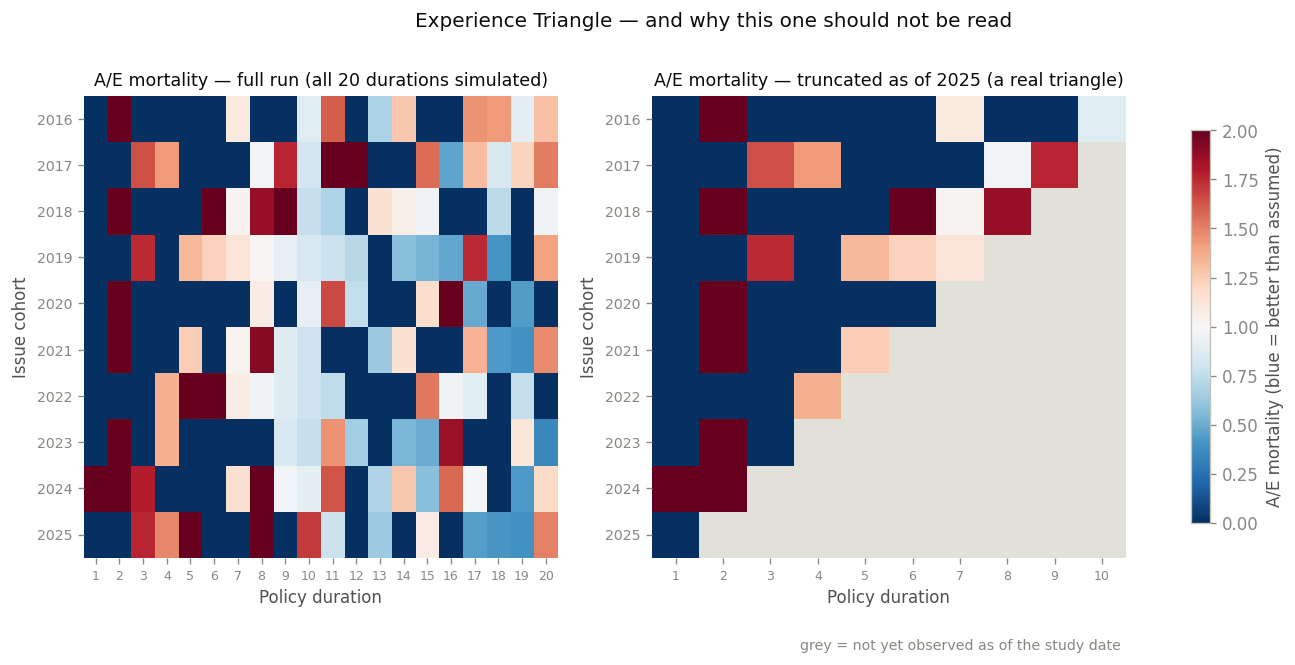

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
norm = TwoSlopeNorm(vmin=0.0, vcenter=1.0, vmax=2.0)

# Unobserved cells must NOT render white -- white sits at A/E = 1.0 on this
# diverging scale, which would read as "exactly as assumed" rather than "no data".
cmap = plt.get_cmap("RdBu_r").copy()
cmap.set_bad(GRID)

for ax, data, title in (
    (ax1, full_mortality, "A/E mortality — full run (all 20 durations simulated)"),
    (ax2, truncated_mortality, f"A/E mortality — truncated as of {AS_OF_YEAR} (a real triangle)"),
):
    mesh = ax.imshow(np.ma.masked_invalid(data.values), cmap=cmap, norm=norm, aspect="auto")
    ax.set_xticks(range(len(data.columns)))
    ax.set_xticklabels(data.columns, fontsize=7.5)
    ax.set_yticks(range(len(data.index)))
    ax.set_yticklabels(data.index, fontsize=8.5)
    ax.set_xlabel("Policy duration")
    ax.set_ylabel("Issue cohort")
    ax.set_title(title, fontsize=10.5)
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.colorbar(mesh, ax=[ax1, ax2], label="A/E mortality (blue = better than assumed)", shrink=0.85)
ax2.text(0.99, -0.20, "grey = not yet observed as of the study date",
         transform=ax2.transAxes, ha="right", fontsize=8.5, color=MUTED)
fig.suptitle("Experience Triangle — and why this one should not be read", fontsize=12, y=1.02)
plt.show()

The triangle *looks* sophisticated and is almost entirely noise. With roughly 1.4 expected deaths
per cell in the full rectangle — and well under one in the truncated version — most cells contain
zero or one actual death, so each cell's A/E is essentially a coin flip rendered in colour. This is
the visual form of Part 5's warning: a chart can be methodologically correct and still carry no
information.

The disciplined way to ask the cohort-vs-duration question at this sample size is to collapse to
the margins, where the counts are large enough to say something.

In [20]:
def duration_band(policy_year):
    if policy_year <= 5:
        return "1-5"
    if policy_year <= 10:
        return "6-10"
    if policy_year <= 15:
        return "11-15"
    return "16-20"


enriched["duration_band"] = enriched["policy_year"].apply(duration_band)
band_order = ["1-5", "6-10", "11-15", "16-20"]

by_duration_band = ae_table(enriched, ["duration_band"], kind="mortality").set_index("duration_band").reindex(band_order).reset_index()
by_cohort = ae_table(enriched, ["issue_cohort"], kind="mortality")

# The simulator's own "true" duration multipliers -- the answer we should recover.
true_multipliers = ASSUMPTIONS.true_mortality_multiplier_by_duration
true_by_band = {
    band: np.mean([true_multipliers[d] for d in range(1, 21) if duration_band(d) == band])
    for band in band_order
}
by_duration_band["true_multiplier"] = by_duration_band["duration_band"].map(true_by_band)

print("=== Duration margin (grouped for credibility) ===")
print(by_duration_band[["duration_band", "actual", "expected", "ae", "ae_lower", "ae_upper", "true_multiplier"]]
      .to_string(index=False, float_format=lambda x: f"{x:,.3f}"))
print()
print("=== Issue-cohort margin (simulation contains NO cohort effect) ===")
print(by_cohort[["issue_cohort", "actual", "expected", "ae", "ae_lower", "ae_upper"]]
      .to_string(index=False, float_format=lambda x: f"{x:,.3f}"))

=== Duration margin (grouped for credibility) ===
duration_band  actual  expected    ae  ae_lower  ae_upper  true_multiplier
          1-5      22    27.704 0.794     0.498     1.202            0.846
         6-10      45    50.778 0.886     0.646     1.186            0.790
        11-15      53    78.998 0.671     0.503     0.878            0.752
        16-20      84   118.430 0.709     0.566     0.878            0.735

=== Issue-cohort margin (simulation contains NO cohort effect) ===
 issue_cohort  actual  expected    ae  ae_lower  ae_upper
         2016      19    25.586 0.743     0.447     1.160
         2017      29    28.011 1.035     0.693     1.487
         2018      22    30.527 0.721     0.452     1.091
         2019      21    27.843 0.754     0.467     1.153
         2020      14    25.203 0.555     0.304     0.932
         2021      19    28.088 0.676     0.407     1.056
         2022      19    28.482 0.667     0.402     1.042
         2023      17    29.218 0.582     0

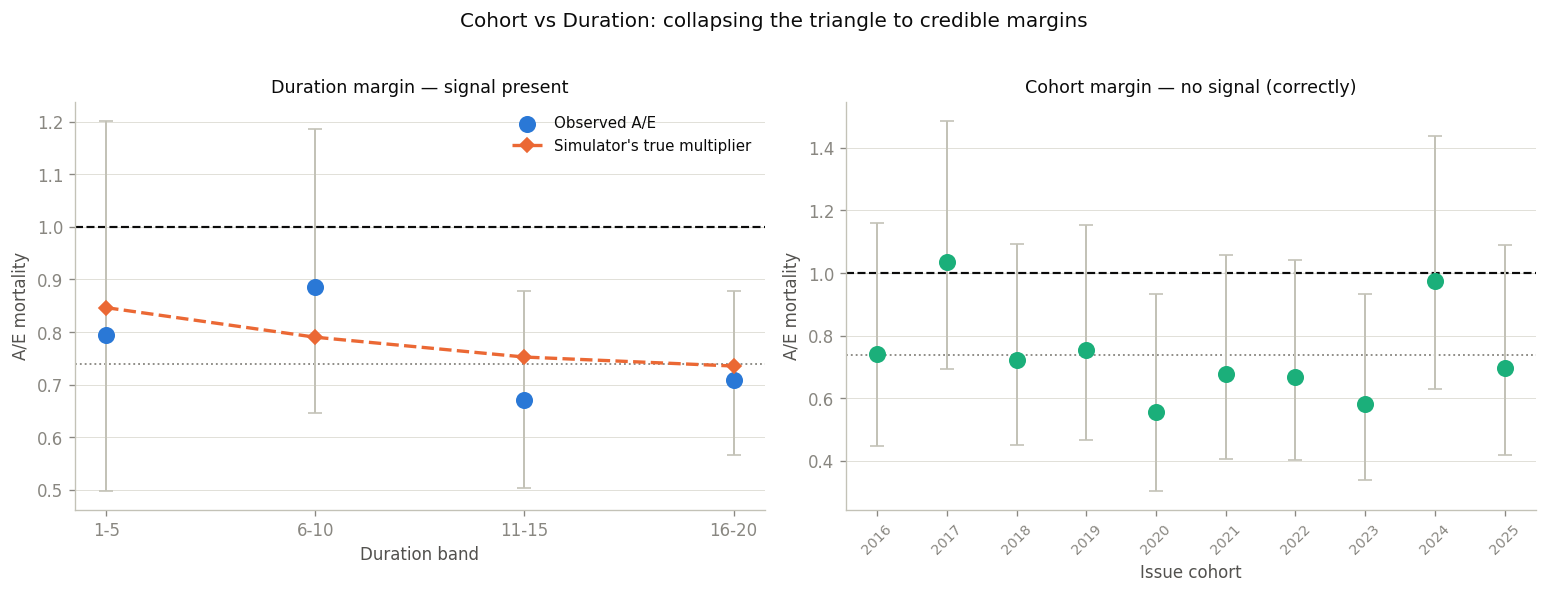

In [21]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.8))

positions = np.arange(len(by_duration_band))
ax1.errorbar(positions, by_duration_band["ae"],
             yerr=[by_duration_band["ae"] - by_duration_band["ae_lower"],
                   by_duration_band["ae_upper"] - by_duration_band["ae"]],
             fmt="none", ecolor=BASELINE, elinewidth=1.2, capsize=4, zorder=2)
ax1.scatter(positions, by_duration_band["ae"], s=85, color=BLUE, zorder=3, label="Observed A/E")
ax1.plot(positions, by_duration_band["true_multiplier"], color=ORANGE, marker="D", markersize=6,
         linewidth=2, linestyle="--", zorder=3, label="Simulator's true multiplier")
ax1.set_xticks(positions)
ax1.set_xticklabels(by_duration_band["duration_band"])
ax1.set_xlabel("Duration band")
ax1.set_title("Duration margin — signal present", fontsize=10.5)
ax1.legend(frameon=False, fontsize=9)

cohort_positions = np.arange(len(by_cohort))
ax2.errorbar(cohort_positions, by_cohort["ae"],
             yerr=[by_cohort["ae"] - by_cohort["ae_lower"], by_cohort["ae_upper"] - by_cohort["ae"]],
             fmt="none", ecolor=BASELINE, elinewidth=1.2, capsize=4, zorder=2)
ax2.scatter(cohort_positions, by_cohort["ae"], s=85, color=AQUA, zorder=3)
ax2.set_xticks(cohort_positions)
ax2.set_xticklabels(by_cohort["issue_cohort"], rotation=45, fontsize=8.5)
ax2.set_xlabel("Issue cohort")
ax2.set_title("Cohort margin — no signal (correctly)", fontsize=10.5)

for ax in (ax1, ax2):
    ax.axhline(1.0, color=INK, linewidth=1.3, linestyle="--", zorder=1)
    ax.axhline(overall["ae_mortality"], color=MUTED, linewidth=1.1, linestyle=":", zorder=1)
    ax.set_ylabel("A/E mortality")
    style(ax)

fig.suptitle("Cohort vs Duration: collapsing the triangle to credible margins", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

This is a genuine validation of the method. The simulator's "true" basis varies **only by
duration** — declining from about 0.85 in durations 1–5 to about 0.74 in durations 16–20 — and
contains no issue-cohort effect whatsoever. The margins recover exactly that: the duration panel
tracks the true multiplier's downward path (imperfectly — the 6–10 band overshoots and 11–15
undershoots, which is what ~50–80 expected deaths per band buys you), while the cohort panel
scatters around the portfolio average with no trend and every interval overlapping.

Had the analysis stopped at the coloured triangle, neither conclusion would have been visible. The
methodology is worth knowing precisely so you can recognise when your data cannot support it.

<a id="Part-8"></a>
## Part 8 — Experience-based assumption update

The naive update takes the observed ratio at face value:

$$ q_x^{new} = (A/E)\, q_x^{old} $$

The credibility-weighted update blends it against the existing assumption:

$$ q_x^{new} = \big[Z(A/E) + (1-Z)\big] q_x^{old} $$

With $Z$ from Part 5, this is the bridge back to pricing: a new mortality basis produces a new
indicated premium.

In [22]:
observed_ae = overall["ae_mortality"]
naive_factor = observed_ae
credibility_factor = Z_mortality * observed_ae + (1 - Z_mortality)

print(f"Observed A/E mortality           = {observed_ae:.4f}")
print(f"Credibility factor Z             = {Z_mortality:.4f}")
print()
print(f"Naive update factor              = {naive_factor:.4f}   (q_new = {naive_factor:.4f} x q_old)")
print(f"Credibility-weighted factor      = {credibility_factor:.4f}   (q_new = {credibility_factor:.4f} x q_old)")
print()
print(f"The credibility weighting keeps {1 - Z_mortality:.1%} of the original assumption, "
      f"moving only {Z_mortality:.1%} of the way toward observed experience.")

Observed A/E mortality           = 0.7394
Credibility factor Z             = 0.5049

Naive update factor              = 0.7394   (q_new = 0.7394 x q_old)
Credibility-weighted factor      = 0.8684   (q_new = 0.8684 x q_old)

The credibility weighting keeps 49.5% of the original assumption, moving only 50.5% of the way toward observed experience.


In [23]:
REPRICE_POLICY = dict(issue_age=40, sex="male", smoker_status="nonsmoker",
                      underwriting_class="Standard", face_amount=500_000)

qx_old = list(mortality_curve_for_policy(ASSUMPTIONS, **REPRICE_POLICY))


def premium_under_mortality(qx_curve):
    projection = project_policy(
        ASSUMPTIONS, issue_age=REPRICE_POLICY["issue_age"],
        mortality_rates_qx=qx_curve, face_amount=REPRICE_POLICY["face_amount"],
    )
    return solve_annual_premium(ASSUMPTIONS, projection)


premium_old = premium_under_mortality(qx_old)
premium_credibility = premium_under_mortality([q * credibility_factor for q in qx_old])
premium_naive = premium_under_mortality([q * naive_factor for q in qx_old])

repricing = pd.DataFrame({
    "Basis": ["Current assumption", "Credibility-weighted update", "Naive full-A/E update"],
    "Mortality factor": [1.0, credibility_factor, naive_factor],
    "Indicated premium": [premium_old, premium_credibility, premium_naive],
})
repricing["Change vs current"] = repricing["Indicated premium"] / premium_old - 1

repricing_display = repricing.copy()
repricing_display["Mortality factor"] = repricing_display["Mortality factor"].map(lambda x: f"{x:.4f}")
repricing_display["Indicated premium"] = repricing_display["Indicated premium"].map(lambda x: f"${x:,.2f}")
repricing_display["Change vs current"] = repricing_display["Change vs current"].map(lambda x: f"{x:+.2%}")
repricing_display.set_index("Basis")

,Mortality factor,Indicated premium,Change vs current
Basis,,,
Current assumption,1.0000,$665.19,+0.00%
Credibility-weighted update,0.8684,$589.77,-11.34%
Naive full-A/E update,0.7394,$515.71,-22.47%


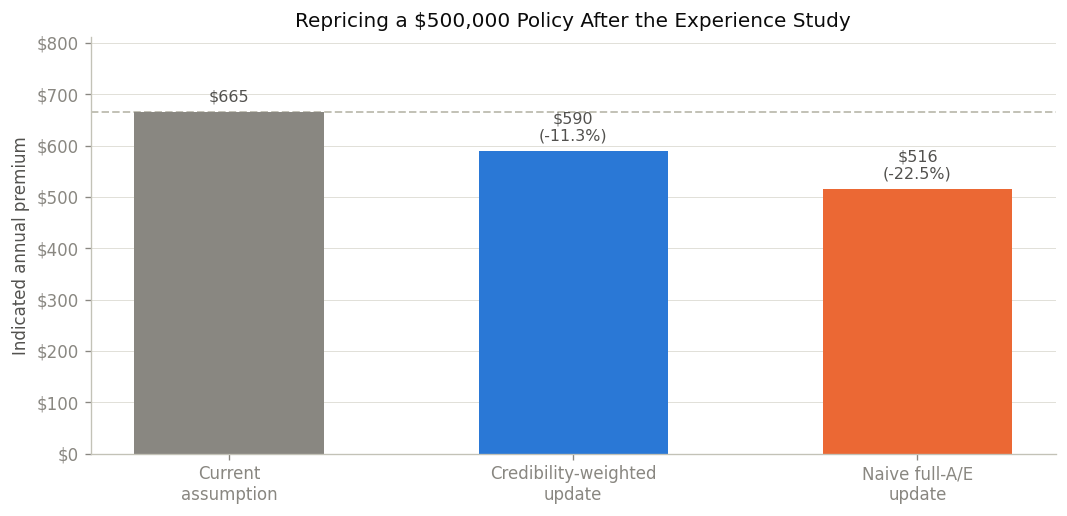

In [24]:
fig, ax = plt.subplots(figsize=(9, 4.4))

labels = ["Current\nassumption", "Credibility-weighted\nupdate", "Naive full-A/E\nupdate"]
values = repricing["Indicated premium"]
colors = [MUTED, BLUE, ORANGE]
bars = ax.bar(labels, values, color=colors, width=0.55, zorder=2)

ax.axhline(premium_old, color=BASELINE, linewidth=1.2, linestyle="--", zorder=1)
ax.set_ylabel("Indicated annual premium")
ax.set_title("Repricing a $500,000 Policy After the Experience Study")
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: f"${x:,.0f}"))
ax.set_ylim(0, values.max() * 1.22)
style(ax)

for bar, value, change in zip(bars, values, repricing["Change vs current"]):
    label = f"${value:,.0f}" + (f"\n({change:+.1%})" if abs(change) > 1e-9 else "")
    ax.text(bar.get_x() + bar.get_width() / 2, value + values.max() * 0.03, label,
            ha="center", fontsize=9.5, color=SECONDARY_INK)

plt.tight_layout()
plt.show()

### What the study concludes

The naive update would cut the premium by more than a fifth on the strength of 204 observed deaths.
The credibility-weighted update moves roughly half as far, and that is the defensible answer: the
evidence genuinely points to mortality running below the pricing basis, but 204 deaths against a
1,082-claim standard does not license taking the observed ratio at face value.

The three findings that would go into the memo:

1. **Mortality is running below assumption** at roughly $A/E = 0.74$, consistently across
   durations and segments and with no sign of an emerging deterioration. Partially credible
   ($Z \approx 0.50$) — enough to support a modest reduction, not the full indicated one.
2. **No segment relativity is contradicted by the evidence.** Every segment interval overlaps the
   portfolio average; the apparent spread is no larger than the spread across issue cohorts, where
   no true effect exists.
3. **Lapse experience is fully credible and does contradict the assumption** — running above
   assumption in early durations and well below at duration 20, where the assumed end-of-level-
   period shock lapse looks too severe. Given notebook 05's finding that this product is
   lapse-supported, that duration-20 result has direct profitability consequences and deserves
   attention before the mortality change.

The last point is the one an experience-study actuary would lead with, and it only becomes visible
once credibility is attached to every ratio rather than ranking segments by A/E alone.